In [ ]:
"""
Summary statistics for inflation and forecasted inflation, 
"""

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats

# ---------------------------------------------------------------
# Load data
# ---------------------------------------------------------------
excel_path = Path.cwd() / 'Aggregate_CPI_inflation_20230513.xls'
xls = pd.ExcelFile(excel_path)

data_quarter = xls.parse(xls.sheet_names[0], skiprows=2)
data_month   = xls.parse(xls.sheet_names[1], skiprows=2)

data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation',
                        'Forecasted inflation', 'Inflation shock']
data_month.columns   = ['Year', 'Month',   'Price index', 'Inflation',
                        'Forecasted inflation', 'Inflation shock']

# ---------------------------------------------------------------
# Build proper time index (helpful for sample range reporting)
# ---------------------------------------------------------------
data_quarter['Date'] = pd.PeriodIndex.from_fields(
    year=data_quarter['Year'], quarter=data_quarter['Quarter'], freq='Q'
)
data_month['Date'] = pd.to_datetime(
    dict(year=data_month['Year'], month=data_month['Month'], day=1)
).dt.to_period('M')


# ---------------------------------------------------------------
# Summary-stats function (asset-pricing conventions)
# ---------------------------------------------------------------
def summarize(series: pd.Series) -> dict:
    """Return the summary stats commonly reported in empirical AP papers."""
    s = series.dropna().astype(float)
    n = len(s)

    # Newey-West / autocorrelations at a few lags (very common in AP)
    def autocorr(x, lag):
        return x.autocorr(lag=lag) if lag < len(x) else np.nan

    out = {
        '#Observations'        : n,
        'Mean'     : s.mean(),
        'Median'   : s.median(),
        'Std'      : s.std(ddof=1),
        'Min'      : s.min(),
        'Max'      : s.max(),
        'P5'       : s.quantile(0.05),
        'P25'      : s.quantile(0.25),
        'P75'      : s.quantile(0.75),
        'P95'      : s.quantile(0.95),
        'Skewness' : stats.skew(s, bias=False),
        'Kurtosis' : stats.kurtosis(s, fisher=True, bias=False),  # excess kurtosis
        'AC(1)'    : autocorr(s, 1),
        'AC(2)'    : autocorr(s, 2),
        'AC(4)'    : autocorr(s, 4),
        'AC(12)'   : autocorr(s, 12),
    }
    return out


def build_table(df: pd.DataFrame, freq_label: str) -> pd.DataFrame:
    cols = ['Inflation', 'Forecasted inflation', 'Inflation shock']
    rows = {}
    for c in cols:
        sub = df[['Date', c]].dropna()
        stat = summarize(sub[c])
        stat = {
            'Date Start'        : str(sub['Date'].iloc[0]),
            'Date End'          : str(sub['Date'].iloc[-1]),
            **stat,
        }
        rows[c] = stat
    table = pd.DataFrame(rows).T
    table.index.name = f'{freq_label} sample'
    return table


# ---------------------------------------------------------------
# Build & print
# ---------------------------------------------------------------
quarter_table = build_table(data_quarter, 'Quarterly')
month_table   = build_table(data_month,   'Monthly')


# ---------------------------------------------------------------
# Build & print
# ---------------------------------------------------------------
quarter_table = build_table(data_quarter, 'Quarterly').T
month_table   = build_table(data_month,   'Monthly').T

# Pretty print
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 50)

print('=' * 90)
print('QUARTERLY SHEET — Summary Statistics')
print('=' * 90)
print(quarter_table.to_string())
print('\n' + '=' * 90)
print('MONTHLY SHEET — Summary Statistics')
print('=' * 90)
print(month_table.to_string())

# ---------------------------------------------------------------
# Save summary as Markdown (no vertical bars)
# ---------------------------------------------------------------
# ---------------------------------------------------------------
# Save summary as Markdown (no vertical bars, 4 decimal places)
# ---------------------------------------------------------------
# ---------------------------------------------------------------
# Save summary as Markdown (GitHub-flavored, 4 decimal places)
# ---------------------------------------------------------------
def fmt(x):
    if isinstance(x, str):
        return x
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, (float, np.floating)):
        if float(x).is_integer():
            return str(int(x))
        return f'{x:.4f}'
    return str(x)

def to_md(table: pd.DataFrame) -> str:
    # First column = row labels (left-aligned); data columns right-aligned.
    n_data_cols = table.shape[1]
    return table.map(fmt).to_markdown(
        tablefmt='pipe',
        colalign=('left',) + ('right',) * n_data_cols,
    )

with open('inflation_summary_stats.md', 'w') as f:
    f.write('# Inflation Summary Statistics\n\n')
    f.write('## Quarterly Sheet\n\n')
    f.write(to_md(quarter_table))
    f.write('\n\n## Monthly Sheet\n\n')
    f.write(to_md(month_table))
    f.write('\n')

print('\nSaved → inflation_summary_stats.md')

QUARTERLY SHEET — Summary Statistics
Quarterly sample Inflation Forecasted inflation Inflation shock
Date Start          1947Q2               1969Q1          1969Q1
Date End            2022Q4               2022Q4          2022Q4
#Observations          303                  216             216
Mean                0.8686               0.8319          0.1618
Median              0.7246               0.6310          0.1112
Std                 0.8640               0.4957          0.6633
Min                -3.4170               0.1048         -4.0117
Max                 4.1612               2.4566          2.1729
P5                 -0.1861               0.3482         -0.7677
P25                 0.4187               0.4748         -0.1666
P75                 1.1758               1.0147          0.4738
P95                 2.5669               2.0006          1.2571
Skewness            0.6203               1.3670         -0.7204
Kurtosis            3.0886               1.2257          7.3167
AC(

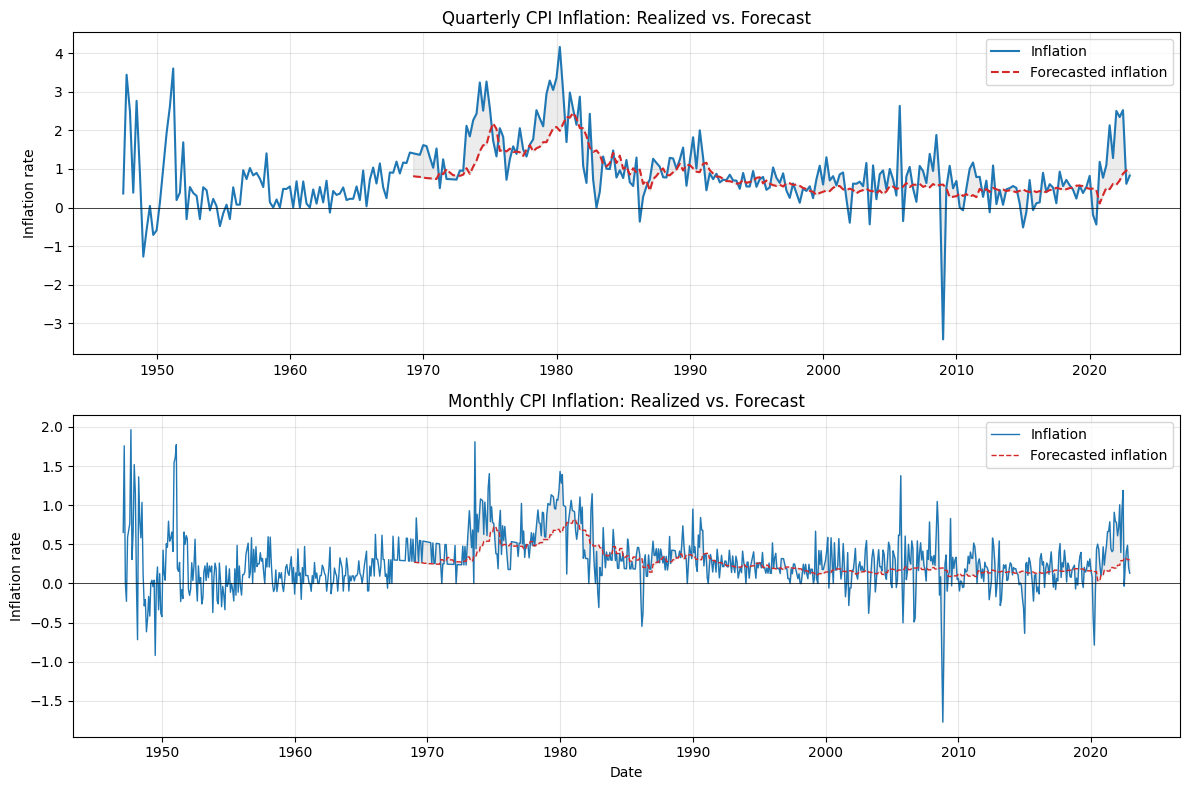

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Load Excel
excel_path = Path.cwd() / 'Aggregate_CPI_inflation_20230513.xls'
xls = pd.ExcelFile(excel_path)

data_quarter = xls.parse(xls.sheet_names[0], skiprows=2)
data_month   = xls.parse(xls.sheet_names[1], skiprows=2)

data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
data_month.columns   = ['Year', 'Month',   'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']

# Datetime index
data_quarter.index = pd.PeriodIndex.from_fields(
    year=data_quarter['Year'], quarter=data_quarter['Quarter'], freq='Q'
).to_timestamp(how='end').normalize()

data_month.index = pd.to_datetime(data_month[['Year', 'Month']].assign(day=1))


fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Quarterly
ax = axes[0]
ax.plot(data_quarter.index, data_quarter['Inflation'],
        label='Inflation', color='#1f77b4', linewidth=1.5)
ax.plot(data_quarter.index, data_quarter['Forecasted inflation'],
        label='Forecasted inflation', color='#d62728', linewidth=1.5, linestyle='--')
ax.fill_between(data_quarter.index,
                data_quarter['Inflation'],
                data_quarter['Forecasted inflation'],
                alpha=0.15, color='gray')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Quarterly CPI Inflation: Realized vs. Forecast')
ax.set_ylabel('Inflation rate')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Monthly
ax = axes[1]
ax.plot(data_month.index, data_month['Inflation'],
        label='Inflation', color='#1f77b4', linewidth=1.0)
ax.plot(data_month.index, data_month['Forecasted inflation'],
        label='Forecasted inflation', color='#d62728', linewidth=1.0, linestyle='--')
ax.fill_between(data_month.index,
                data_month['Inflation'],
                data_month['Forecasted inflation'],
                alpha=0.15, color='gray')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Monthly CPI Inflation: Realized vs. Forecast')
ax.set_ylabel('Inflation rate')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('cpi_inflation.png', dpi=300, bbox_inches='tight')
plt.show()